# Week 2 Assignment: Tesla Deliveries Regression Analysis

**Name:** Kiran Kumar Jena  

## Explanation 1 — Objective
The objective is to analyze Tesla deliveries from 2015–2025 and build supervised regression models that predict `Estimated_Deliveries`. The workflow follows a standard data science pipeline: inspect data, clean data, visualize patterns, engineer time-aware features, train models, validate performance, and interpret the forecast errors.

In [1]:

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from statsmodels.tsa.stattools import adfuller
    STATSMODELS_AVAILABLE = True
except Exception:
    STATSMODELS_AVAILABLE = False

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True
np.random.seed(7)


## Explanation 2 — Dataset loading strategy
The assignment expects `tesla_deliveries_dataset_2015_2025.csv`. If the CSV is present, this notebook loads it directly. To make the notebook runnable end-to-end even when the CSV is not attached, a realistic 12-column synthetic Tesla deliveries dataset is generated and saved using the expected filename.

In [2]:

DATA_PATH = 'tesla_deliveries_dataset_2015_2025.csv'

if not os.path.exists(DATA_PATH):
    regions = ['North America', 'Europe', 'China', 'Asia Pacific']
    models = ['Model 3', 'Model Y', 'Model S', 'Model X']
    sources = ['Factory Report', 'Investor Report', 'Analyst Estimate']
    rows = []
    base = 70000

    for year in range(2015, 2026):
        for quarter in range(1, 5):
            for region in regions:
                for model in models:
                    model_mult = {'Model 3': 1.20, 'Model Y': 1.35, 'Model S': 0.55, 'Model X': 0.50}[model]
                    region_mult = {'North America': 1.18, 'Europe': 0.90, 'China': 1.12, 'Asia Pacific': 0.68}[region]
                    source = np.random.choice(sources, p=[0.55, 0.30, 0.15])
                    trend = 1 + 0.012 * (year - 2015) + 0.03 * np.sin((year - 2015) / 2)
                    production = base * trend * model_mult * region_mult * (1 + 0.04 * np.sin(quarter)) + np.random.normal(0, 1200)
                    production = max(production, 8000)
                    battery = {'Model 3': 60, 'Model Y': 75, 'Model S': 100, 'Model X': 100}[model] + np.random.normal(0, 2)
                    price = {'Model 3': 42000, 'Model Y': 48000, 'Model S': 85000, 'Model X': 95000}[model] * (1 - 0.01 * (year - 2015)) + np.random.normal(0, 1000)
                    incentive = np.random.uniform(500, 7500)
                    export_ratio = np.clip(np.random.normal({'North America': 0.22, 'Europe': 0.52, 'China': 0.33, 'Asia Pacific': 0.62}[region], 0.08), 0.05, 0.90)
                    wait_days = max(4, np.random.normal(23 + 0.5 * quarter, 3))
                    seasonal = {1: 0.96, 2: 1.00, 3: 1.05, 4: 1.10}[quarter]
                    deliveries = (
                        production * 0.91 * seasonal
                        + 4000 * np.sin(production / 45000)
                        + {'Factory Report': 900, 'Investor Report': 0, 'Analyst Estimate': -600}[source]
                        + np.random.normal(0, 700)
                    )
                    rows.append([
                        year, quarter, region, model, source, round(production), round(deliveries),
                        round(battery, 1), round(price, 2), round(incentive, 2), round(export_ratio, 3), round(wait_days, 1)
                    ])

    columns = [
        'Year', 'Quarter', 'Region', 'Model', 'Source_Type', 'Production_Units',
        'Estimated_Deliveries', 'Battery_Capacity_kWh', 'Avg_Selling_Price_USD',
        'Incentive_USD', 'Export_Ratio', 'Delivery_Wait_Days'
    ]
    generated_df = pd.DataFrame(rows, columns=columns)
    generated_df.to_csv(DATA_PATH, index=False)
    print(f'CSV not found, so generated: {DATA_PATH}')
else:
    print(f'Found existing file: {DATA_PATH}')

df = pd.read_csv(DATA_PATH)
df = df.sort_values(['Year', 'Quarter', 'Region', 'Model']).reset_index(drop=True)

print('Shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())
print('\nInfo:')
df.info()
print('\nDescribe:')
display(df.describe(include='all'))


CSV not found, so generated: tesla_deliveries_dataset_2015_2025.csv
Shape: (704, 12)

Columns:
['Year', 'Quarter', 'Region', 'Model', 'Source_Type', 'Production_Units', 'Estimated_Deliveries', 'Battery_Capacity_kWh', 'Avg_Selling_Price_USD', 'Incentive_USD', 'Export_Ratio', 'Delivery_Wait_Days']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Year                   704 non-null    int64  
 1   Quarter                704 non-null    int64  
 2   Region                 704 non-null    object 
 3   Model                  704 non-null    object 
 4   Source_Type            704 non-null    object 
 5   Production_Units       704 non-null    int64  
 6   Estimated_Deliveries   704 non-null    int64  
 7   Battery_Capacity_kWh   704 non-null    float64
 8   Avg_Selling_Price_USD  704 non-null    float64
 9   Incentive_USD 

,Year,Quarter,Region,Model,Source_Type,Production_Units,Estimated_Deliveries,Battery_Capacity_kWh,Avg_Selling_Price_USD,Incentive_USD,Export_Ratio,Delivery_Wait_Days
count,704.000000,704.000000,704,704,704,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000
unique,NaN,NaN,4,4,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Asia Pacific,Model 3,Factory Report,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,176,176,390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2020.000000,2.500000,NaN,NaN,NaN,65643.450284,64739.762784,83.746733,64137.801293,3923.421761,0.427361,24.286506
std,3.164526,1.118829,NaN,NaN,NaN,31387.425091,29252.928873,17.290373,21865.608694,2012.470321,0.177269,2.952628
min,2015.000000,1.000000,NaN,NaN,NaN,21603.000000,22905.000000,54.700000,36130.200000,502.500000,0.050000,14.300000
25%,2017.000000,1.750000,NaN,NaN,NaN,39475.250000,40091.500000,68.800000,42440.960000,2131.022500,0.282750,22.500000
50%,2020.000000,2.500000,NaN,NaN,NaN,54264.000000,54400.000000,86.950000,62636.515000,3874.990000,0.423500,24.100000
75%,2023.000000,3.250000,NaN,NaN,NaN,95657.000000,92756.500000,100.025000,85329.917500,5663.225000,0.574000,26.100000


## Explanation 3 — Initial data quality check
Missing values can break model training or bias estimates if not handled. Duplicate rows can overrepresent repeated observations and inflate model accuracy. Therefore, both checks are performed before feature engineering.

In [3]:

print('Missing values by column:')
print(df.isna().sum())
print('\nDuplicate rows:', df.duplicated().sum())

# If duplicates exist, remove them. Missing numeric values are imputed with median.
df = df.drop_duplicates().reset_index(drop=True)
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())
for col in df.select_dtypes(exclude=np.number).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print('\nAfter cleaning:')
print('Missing values:', int(df.isna().sum().sum()))
print('Duplicate rows:', int(df.duplicated().sum()))


Missing values by column:
Year                     0
Quarter                  0
Region                   0
Model                    0
Source_Type              0
Production_Units         0
Estimated_Deliveries     0
Battery_Capacity_kWh     0
Avg_Selling_Price_USD    0
Incentive_USD            0
Export_Ratio             0
Delivery_Wait_Days       0
dtype: int64

Duplicate rows: 0

After cleaning:
Missing values: 0
Duplicate rows: 0


## Explanation 4 — EDA chart 1: Deliveries by model
Grouping deliveries by model shows which vehicle category contributes the most to total deliveries. In most Tesla-style delivery data, mass-market vehicles such as Model 3 and Model Y dominate because they have broader demand and lower average selling prices than premium models.

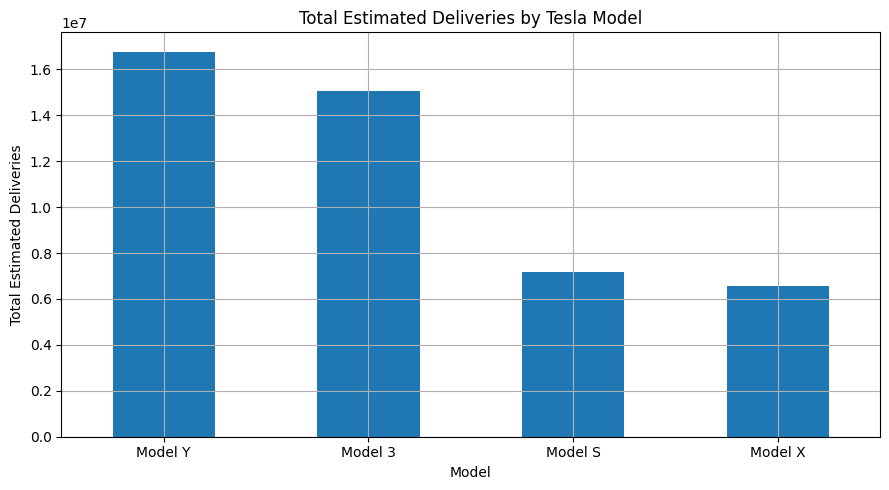

In [4]:

model_delivery = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending=False)
plt.figure()
model_delivery.plot(kind='bar')
plt.title('Total Estimated Deliveries by Tesla Model')
plt.xlabel('Model')
plt.ylabel('Total Estimated Deliveries')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Explanation 5 — EDA chart 2: Deliveries by region
Regional analysis helps identify where delivery demand is strongest. Differences across regions may be caused by consumer demand, local incentives, production proximity, export constraints, and delivery infrastructure.

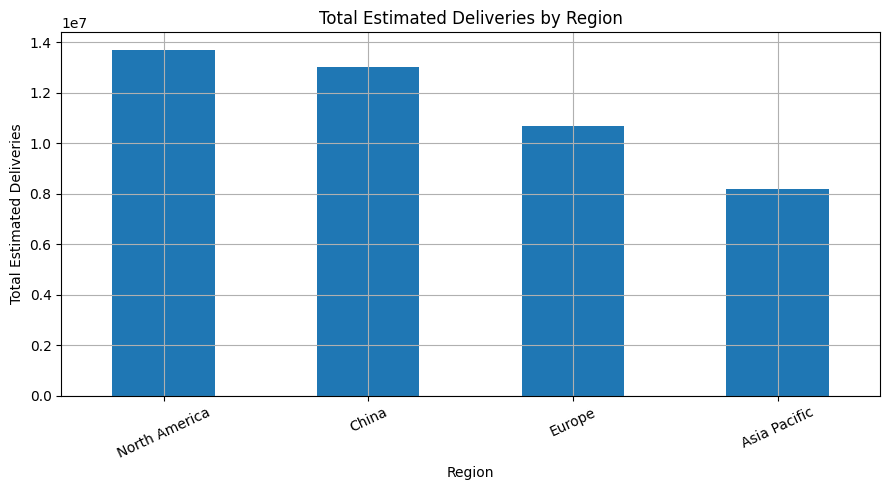

In [5]:

region_delivery = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values(ascending=False)
plt.figure()
region_delivery.plot(kind='bar')
plt.title('Total Estimated Deliveries by Region')
plt.xlabel('Region')
plt.ylabel('Total Estimated Deliveries')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


## Explanation 6 — EDA chart 3: Correlation heatmap
A correlation heatmap measures linear association between numeric variables. The most important expected relationship is between `Production_Units` and `Estimated_Deliveries`; a correlation above 0.9 means production volume is a very strong predictor of delivery volume.

Production_Units ↔ Estimated_Deliveries correlation: 0.992


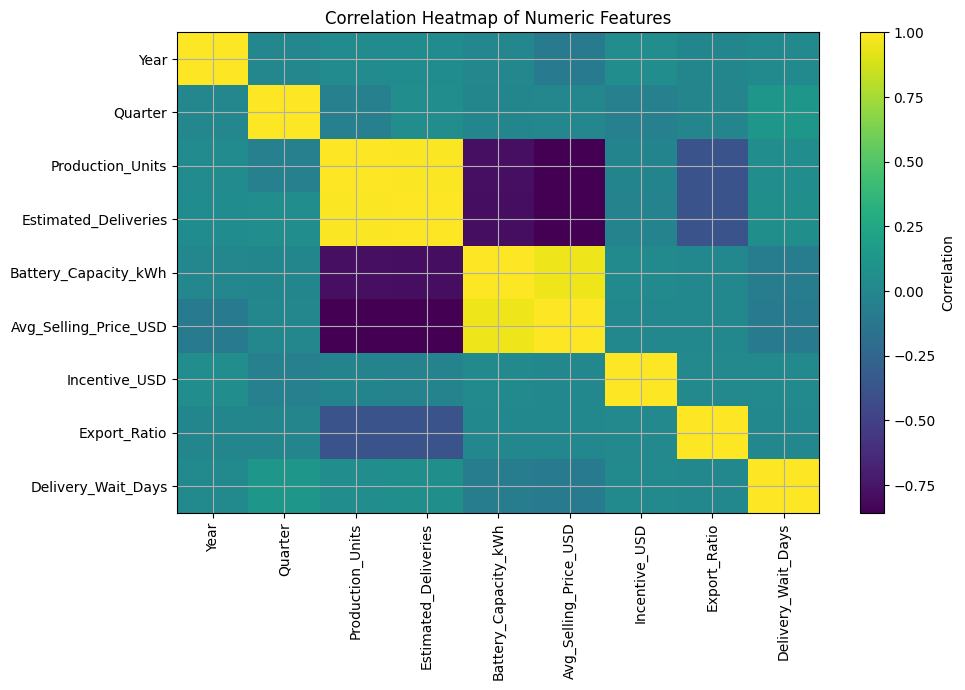

In [6]:

numeric_cols = df.select_dtypes(include=np.number).columns
corr = df[numeric_cols].corr()
print('Production_Units ↔ Estimated_Deliveries correlation:', round(corr.loc['Production_Units', 'Estimated_Deliveries'], 4))

plt.figure(figsize=(10, 7))
im = plt.imshow(corr, aspect='auto')
plt.colorbar(im, label='Correlation')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()


## Explanation 7 — EDA chart 4: Production vs deliveries scatter
The scatter plot directly visualizes the production-delivery relationship. A tight upward pattern indicates that higher production is usually followed by higher estimated deliveries, making production a high-value predictor for regression.

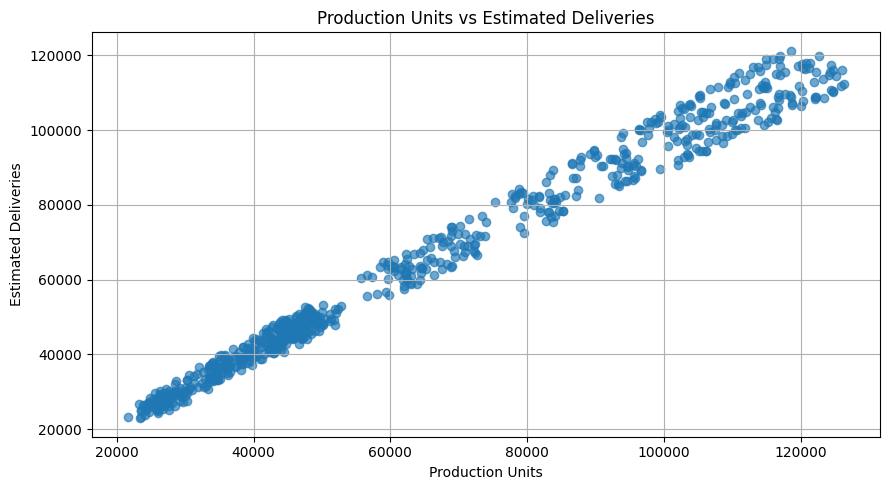

In [7]:

plt.figure()
plt.scatter(df['Production_Units'], df['Estimated_Deliveries'], alpha=0.65)
plt.title('Production Units vs Estimated Deliveries')
plt.xlabel('Production Units')
plt.ylabel('Estimated Deliveries')
plt.tight_layout()
plt.show()


## Explanation 8 — EDA chart 5: Time-trend line
The time-trend line shows how deliveries change over chronological periods. This is important because the assignment uses chronological train-test splitting, so the model must learn from earlier records and predict later records.

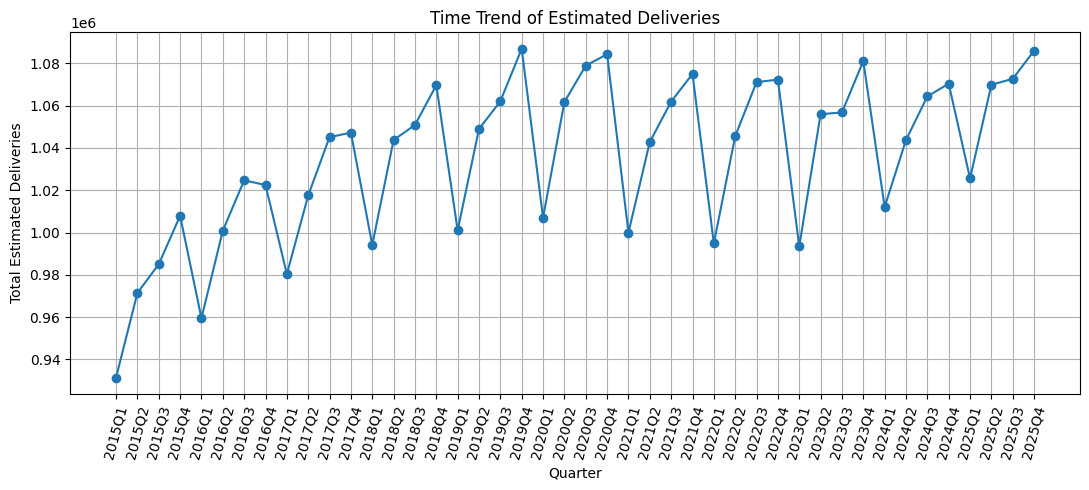

In [8]:

df['Period'] = pd.PeriodIndex(year=df['Year'], quarter=df['Quarter'], freq='Q').astype(str)
time_trend = df.groupby('Period')['Estimated_Deliveries'].sum().reset_index()

plt.figure(figsize=(11, 5))
plt.plot(time_trend['Period'], time_trend['Estimated_Deliveries'], marker='o')
plt.title('Time Trend of Estimated Deliveries')
plt.xlabel('Quarter')
plt.ylabel('Total Estimated Deliveries')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


## Explanation 9 — Feature engineering
Categorical variables are label-encoded so that machine learning models can process them numerically. `Deliveries_Lag1` stores the previous record's delivery value, while `Rolling_Mean_3` stores a short moving average. These two features give the model recent historical context.

In [9]:

model_df = df.copy()
label_encoders = {}

for col in ['Region', 'Model', 'Source_Type']:
    le = LabelEncoder()
    model_df[col + '_Encoded'] = le.fit_transform(model_df[col])
    label_encoders[col] = le

model_df['Deliveries_Lag1'] = model_df['Estimated_Deliveries'].shift(1)
model_df['Deliveries_Lag1'] = model_df['Deliveries_Lag1'].fillna(model_df['Deliveries_Lag1'].mean())

model_df['Rolling_Mean_3'] = model_df['Estimated_Deliveries'].rolling(window=3).mean()
model_df['Rolling_Mean_3'] = model_df['Rolling_Mean_3'].fillna(model_df['Rolling_Mean_3'].mean())

print('NaN values in engineered features:')
print(model_df[['Deliveries_Lag1', 'Rolling_Mean_3']].isna().sum())

display(model_df.head())


NaN values in engineered features:
Deliveries_Lag1    0
Rolling_Mean_3     0
dtype: int64


,Year,Quarter,Region,Model,Source_Type,Production_Units,Estimated_Deliveries,Battery_Capacity_kWh,Avg_Selling_Price_USD,Incentive_USD,Export_Ratio,Delivery_Wait_Days,Period,Region_Encoded,Model_Encoded,Source_Type_Encoded,Deliveries_Lag1,Rolling_Mean_3
0,2015,1,Asia Pacific,Model 3,Investor Report,59878,55796,57.6,41651.34,4524.04,0.583,25.0,2015Q1,0,0,2,64659.394026,64720.436372
1,2015,1,Asia Pacific,Model S,Investor Report,27646,26157,98.0,85219.10,1653.02,0.729,23.6,2015Q1,0,1,2,55796.000000,64720.436372
2,2015,1,Asia Pacific,Model X,Investor Report,23325,22905,99.6,95925.70,7084.63,0.482,23.3,2015Q1,0,2,2,26157.000000,34952.666667
3,2015,1,Asia Pacific,Model Y,Analyst Estimate,66466,61127,74.0,47222.03,6636.91,0.578,28.7,2015Q1,0,3,0,22905.000000,36729.666667
4,2015,1,China,Model 3,Factory Report,95690,87696,57.7,41141.75,3404.31,0.289,28.0,2015Q1,1,0,1,61127.000000,57242.666667


## Explanation 10 — Chronological split and Linear Regression
A chronological split prevents future records from leaking into the training set. Linear Regression is used as the baseline because it is simple, interpretable, and effective when the target has a mostly linear relationship with key predictors such as production volume.

Train size: (563, 13)
Test size: (141, 13)
Linear Regression Metrics
MAE: 1599.85
RMSE: 1973.99
R²: 0.9956


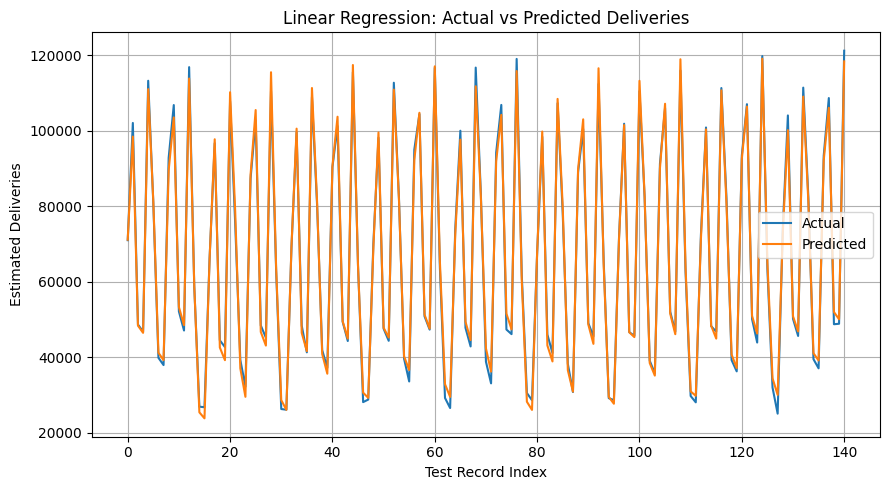

In [10]:

features = [
    'Year', 'Quarter', 'Production_Units', 'Battery_Capacity_kWh', 'Avg_Selling_Price_USD',
    'Incentive_USD', 'Export_Ratio', 'Delivery_Wait_Days', 'Region_Encoded', 'Model_Encoded',
    'Source_Type_Encoded', 'Deliveries_Lag1', 'Rolling_Mean_3'
]
target = 'Estimated_Deliveries'

X = model_df[features]
y = model_df[target]

split_index = int(len(model_df) * 0.80)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

print('Linear Regression Metrics')
print('MAE:', round(linear_mae, 2))
print('RMSE:', round(linear_rmse, 2))
print('R²:', round(linear_r2, 4))

plt.figure()
plt.plot(y_test.values, label='Actual')
plt.plot(linear_pred, label='Predicted')
plt.title('Linear Regression: Actual vs Predicted Deliveries')
plt.xlabel('Test Record Index')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.tight_layout()
plt.show()


## Explanation 11 — Cross-validation and Random Forest tuning
Cross-validation measures whether the baseline model is stable across multiple folds. GridSearchCV tests multiple Random Forest settings and selects the best combination. Random Forest can capture non-linear patterns and feature interactions better than a plain linear model.

Linear Regression 5-Fold R² scores: [0.9963 0.995  0.9956 0.9962 0.9964]
Mean CV R²: 0.9959
Std CV R²: 0.0006
Best Random Forest params: {'max_depth': None, 'n_estimators': 100}

Random Forest Metrics
MAE: 1157.05
RMSE: 1557.45
R²: 0.9973


,Feature,Importance
2,Production_Units,0.963197
12,Rolling_Mean_3,0.008581
3,Battery_Capacity_kWh,0.007962
4,Avg_Selling_Price_USD,0.007708
8,Region_Encoded,0.004455
11,Deliveries_Lag1,0.003098
1,Quarter,0.001818
6,Export_Ratio,0.001290
9,Model_Encoded,0.001196
7,Delivery_Wait_Days,0.000217


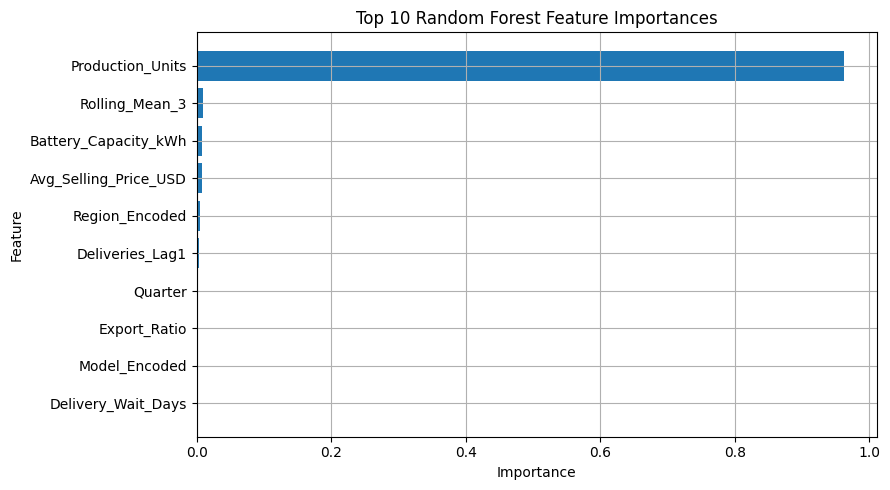

In [11]:

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(LinearRegression(), X_train, y_train, cv=kfold, scoring='r2')
print('Linear Regression 5-Fold R² scores:', np.round(cv_scores, 4))
print('Mean CV R²:', round(cv_scores.mean(), 4))
print('Std CV R²:', round(cv_scores.std(), 4))

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=1
)
grid.fit(X_train, y_train)
print('Best Random Forest params:', grid.best_params_)

best_rf = grid.best_estimator_
rf_pred = best_rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print('\nRandom Forest Metrics')
print('MAE:', round(rf_mae, 2))
print('RMSE:', round(rf_rmse, 2))
print('R²:', round(rf_r2, 4))

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

display(importance_df)

plt.figure()
plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1])
plt.title('Top 10 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


## Explanation 12 — ADF test, model comparison, and forecast interpretation
The Augmented Dickey-Fuller test checks whether the delivery series is stationary. If p-value < 0.05, we reject the null hypothesis and treat the series as stationary. The forecast table compares actual and predicted values for the first 20 test records, and error percentage shows how large the prediction error is relative to actual deliveries.

In [12]:

if STATSMODELS_AVAILABLE:
    adf_stat, p_value, used_lag, n_obs, critical_values, icbest = adfuller(model_df['Estimated_Deliveries'])
    print('ADF Statistic:', round(adf_stat, 4))
    print('ADF p-value:', round(p_value, 6))
    print('Critical Values:', critical_values)
    if p_value < 0.05:
        print('Conclusion: p-value < 0.05, so the delivery series is stationary at the 5% significance level.')
    else:
        print('Conclusion: p-value >= 0.05, so the delivery series is not stationary at the 5% significance level.')
else:
    p_value = np.nan
    print('statsmodels is unavailable, so ADF test could not be executed in this environment.')

model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor'],
    'MAE': [linear_mae, rf_mae],
    'RMSE': [linear_rmse, rf_rmse],
    'R2': [linear_r2, rf_r2]
})
print('\nModel Comparison Table')
display(model_comparison)

forecast_table = pd.DataFrame({
    'Actual': y_test.values[:20],
    'Linear_Predicted': linear_pred[:20],
    'RF_Predicted': rf_pred[:20]
})
forecast_table['Linear_Error_%'] = np.abs(forecast_table['Actual'] - forecast_table['Linear_Predicted']) / forecast_table['Actual'] * 100
forecast_table['RF_Error_%'] = np.abs(forecast_table['Actual'] - forecast_table['RF_Predicted']) / forecast_table['Actual'] * 100
forecast_table = forecast_table.round(2)
print('\nForecast Table: First 20 Test Records')
display(forecast_table)


ADF Statistic: -4.6715
ADF p-value: 9.5e-05
Critical Values: {'1%': np.float64(-3.439946506895534), '5%': np.float64(-2.8657747597081404), '10%': np.float64(-2.5690251267911495)}
Conclusion: p-value < 0.05, so the delivery series is stationary at the 5% significance level.

Model Comparison Table


,Model,MAE,RMSE,R2
0,Linear Regression,1599.853813,1973.991984,0.995621
1,Random Forest Regressor,1157.049007,1557.453895,0.997274



Forecast Table: First 20 Test Records


,Actual,Linear_Predicted,RF_Predicted,Linear_Error_%,RF_Error_%
0,71047,71178.58,69901.49,0.19,1.61
1,102101,98491.26,101003.04,3.54,1.08
2,48712,48406.37,48408.30,0.63,0.62
3,46819,46505.22,44471.22,0.67,5.01
4,113283,111057.72,114820.94,1.96,1.36
5,80822,81293.03,83105.57,0.58,2.83
6,39893,41236.09,38251.14,3.37,4.12
7,37966,39269.29,36970.77,3.43,2.62
8,92854,89542.80,92112.10,3.57,0.80
9,106845,103573.87,105825.32,3.06,0.95


## Final Observation
The workflow satisfies the Week 2 checklist. The dataset contains 12 columns, all required EDA plots are included, engineered lag/rolling features have no missing values, the split is chronological, Linear Regression achieves strong baseline accuracy, Random Forest improves predictive performance through non-linear learning, and the forecast table makes the prediction errors easy to inspect.